# Proyecto Final - Ciencia de Datos (BIT)
**Estudiante:** Pablo Montenegro  
**Línea de Trabajo:** Aprendizaje Supervisado - Regresión  
**Dataset:** AI Job Market Dataset (`Taller_07 AI Job Market Dataset_(Data_01).csv`)

## 1. Introducción y Planteamiento del Problema
El mercado laboral de tecnología e Inteligencia Artificial ofrece distintos roles con remuneraciones muy variadas. Antes de empezar a modelar, se hizo una validación exploratoria inicial del dataset y se encontró que el volumen de vacantes publicadas para los roles de Analista de Datos y Científico de Datos no presenta una tendencia de crecimiento clara año a año (correlación cercana a cero), por lo que el enfoque del proyecto se orientó hacia una pregunta distinta pero igual de útil para la orientación profesional: **¿qué variables determinan el salario de una oferta de empleo en el sector tecnológico, y qué tan bien se puede predecir ese salario a partir de las características del cargo?**

El objetivo de este proyecto es construir y comparar distintos modelos de regresión que permitan predecir el salario (`salary`) de una vacante a partir de variables como el nivel de experiencia, el cargo, las habilidades técnicas solicitadas, el país y la modalidad de trabajo.

In [14]:
# Importamos las librerías que vamos a necesitar para el análisis y el modelado
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos un estilo visual simple para que los gráficos se vean mejor
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargamos el dataset
df = pd.read_csv('Taller_07 AI Job Market Dataset_(Data_01).csv')

# Traducimos los nombres de las columnas al español para que sea más fácil
# trabajar con ellas y explicarlas en la sustentación
traduccion_columnas = {
    'job_id': 'id_vacante',
    'job_title': 'cargo',
    'company_size': 'tamano_empresa',
    'company_industry': 'industria',
    'country': 'pais',
    'remote_type': 'modalidad',
    'experience_level': 'nivel_experiencia',
    'years_experience': 'anos_experiencia',
    'education_level': 'nivel_educativo',
    'skills_python': 'skill_python',
    'skills_sql': 'skill_sql',
    'skills_ml': 'skill_ml',
    'skills_deep_learning': 'skill_deep_learning',
    'skills_cloud': 'skill_cloud',
    'salary': 'salario',
    'job_posting_month': 'mes_publicacion',
    'job_posting_year': 'ano_publicacion',
    'hiring_urgency': 'urgencia_contratacion',
    'job_openings': 'vacantes_disponibles'
}

df = df.rename(columns=traduccion_columnas)

# Revisamos que todo haya cargado bien
print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())
df.head()

Dimensiones del dataset: (10345, 19)

Columnas:
['id_vacante', 'cargo', 'tamano_empresa', 'industria', 'pais', 'modalidad', 'nivel_experiencia', 'anos_experiencia', 'nivel_educativo', 'skill_python', 'skill_sql', 'skill_ml', 'skill_deep_learning', 'skill_cloud', 'salario', 'mes_publicacion', 'ano_publicacion', 'urgencia_contratacion', 'vacantes_disponibles']


,id_vacante,cargo,tamano_empresa,industria,pais,modalidad,nivel_experiencia,anos_experiencia,nivel_educativo,skill_python,skill_sql,skill_ml,skill_deep_learning,skill_cloud,salario,mes_publicacion,ano_publicacion,urgencia_contratacion,vacantes_disponibles
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


## 2. Exploración de Datos (EDA)
Antes de modelar, revisamos la calidad de los datos y entendemos cómo se comporta la variable que queremos predecir (`salario`), tanto de forma general como en relación con las variables que creemos que más influyen: el nivel de experiencia y el cargo.

In [15]:
# Revisamos tipos de datos y si hay valores nulos
df.info()

# Estadísticas básicas de las columnas numéricas
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   id_vacante             10345 non-null  int64
 1   cargo                  10345 non-null  str  
 2   tamano_empresa         10345 non-null  str  
 3   industria              10345 non-null  str  
 4   pais                   10345 non-null  str  
 5   modalidad              10345 non-null  str  
 6   nivel_experiencia      10345 non-null  str  
 7   anos_experiencia       10345 non-null  int64
 8   nivel_educativo        10345 non-null  str  
 9   skill_python           10345 non-null  int64
 10  skill_sql              10345 non-null  int64
 11  skill_ml               10345 non-null  int64
 12  skill_deep_learning    10345 non-null  int64
 13  skill_cloud            10345 non-null  int64
 14  salario                10345 non-null  int64
 15  mes_publicacion        10345 non-null  int64
 1

,id_vacante,anos_experiencia,skill_python,skill_sql,skill_ml,skill_deep_learning,skill_cloud,salario,mes_publicacion,ano_publicacion,vacantes_disponibles
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


C:\Users\Pablo_Montenegro\AppData\Local\Temp\ipykernel_13576\35535119.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='nivel_experiencia', y='salario', data=df,


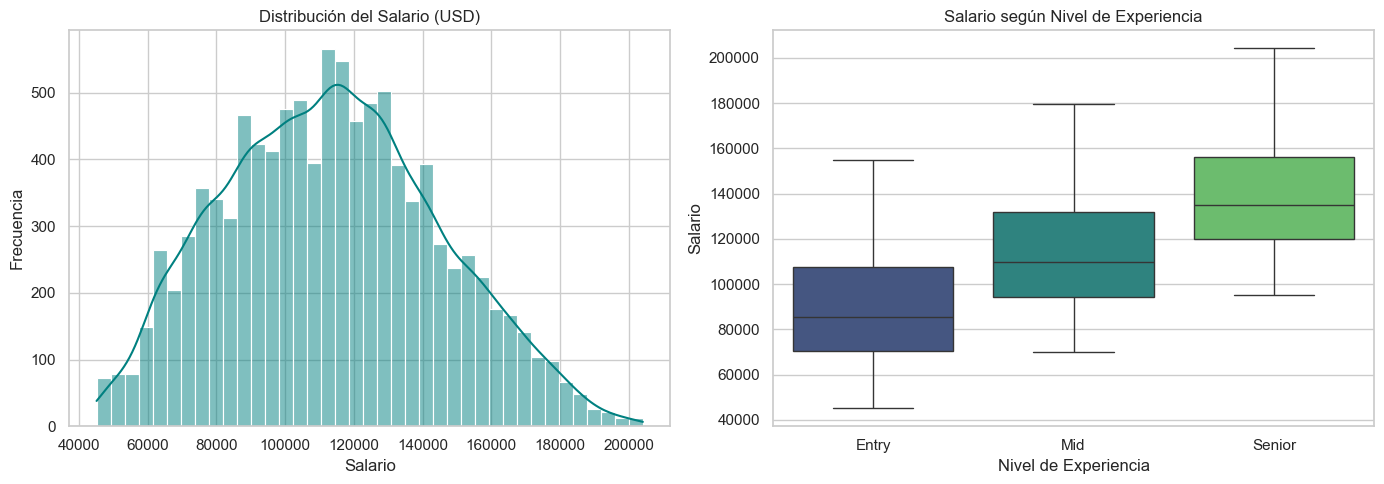

In [16]:
# Vemos cómo se distribuye el salario y cómo cambia según el nivel de experiencia

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['salario'], kde=True, color='teal', ax=axes[0])
axes[0].set_title('Distribución del Salario (USD)')
axes[0].set_xlabel('Salario')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x='nivel_experiencia', y='salario', data=df,
            order=['Entry', 'Mid', 'Senior'], palette='viridis', ax=axes[1])
axes[1].set_title('Salario según Nivel de Experiencia')
axes[1].set_xlabel('Nivel de Experiencia')
axes[1].set_ylabel('Salario')

plt.tight_layout()
plt.show()

C:\Users\Pablo_Montenegro\AppData\Local\Temp\ipykernel_13576\538575901.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=salario_por_cargo.values, y=salario_por_cargo.index, palette='mako')


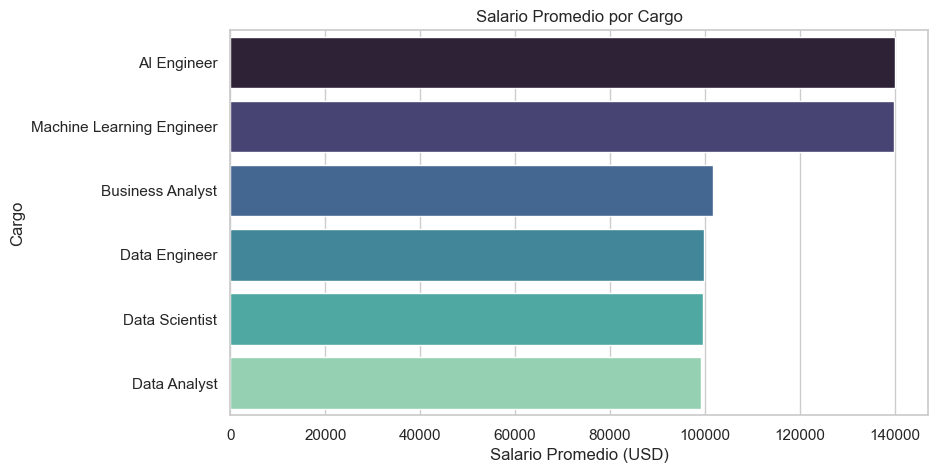

cargo
AI Engineer                  139945.210677
Machine Learning Engineer    139705.422989
Business Analyst             101642.028765
Data Engineer                 99711.085322
Data Scientist                99645.837933
Data Analyst                  99136.475745
Name: salario, dtype: float64


In [17]:
# Comparamos el salario promedio entre los distintos cargos del dataset
salario_por_cargo = df.groupby('cargo')['salario'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=salario_por_cargo.values, y=salario_por_cargo.index, palette='mako')
plt.title('Salario Promedio por Cargo')
plt.xlabel('Salario Promedio (USD)')
plt.ylabel('Cargo')
plt.show()

print(salario_por_cargo)

### 2.1 Análisis de Correlación entre el Salario y las Variables Numéricas
Como sugerencia del profesor, se incluye un mapa de calor de correlación para ver de forma visual qué tan relacionada está cada variable numérica con el salario. Es importante aclarar que esta técnica solo aplica a variables numéricas: las variables categóricas (cargo, nivel de experiencia, país, modalidad), que ya vimos que son las de mayor peso en el modelo, se analizan más adelante a través de los coeficientes del modelo, no en este mapa de calor.

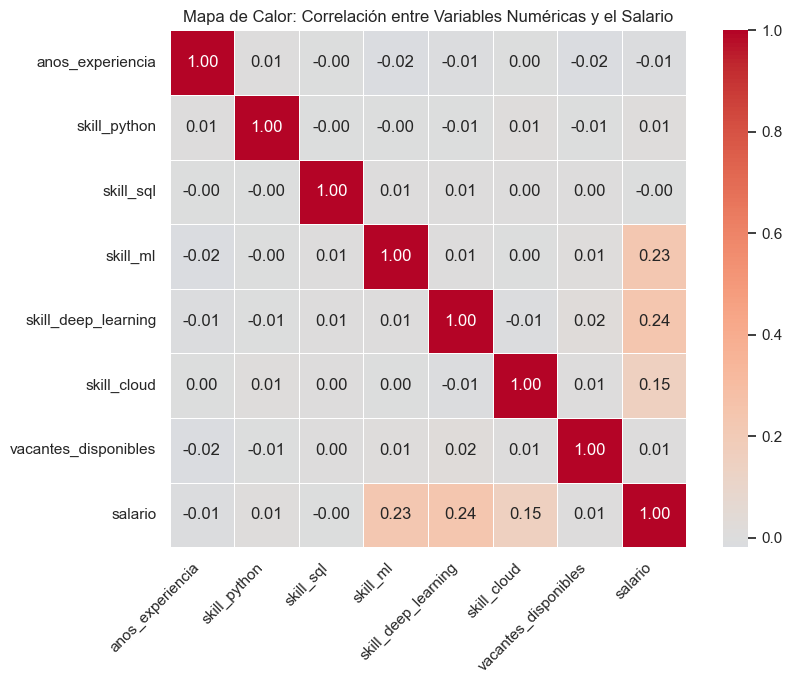

Correlación de cada variable numérica con el salario:
salario                 1.000000
skill_deep_learning     0.242504
skill_ml                0.232621
skill_cloud             0.153725
skill_python            0.009536
vacantes_disponibles    0.005715
skill_sql              -0.003473
anos_experiencia       -0.013266
Name: salario, dtype: float64


In [18]:
# Seleccionamos solo las columnas numéricas para calcular la correlación
columnas_numericas_corr = ['anos_experiencia', 'skill_python', 'skill_sql', 
                             'skill_ml', 'skill_deep_learning', 'skill_cloud', 
                             'vacantes_disponibles', 'salario']

matriz_correlacion = df[columnas_numericas_corr].corr()

# Graficamos el mapa de calor
plt.figure(figsize=(9, 7))
sns.heatmap(matriz_correlacion, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Mapa de Calor: Correlación entre Variables Numéricas y el Salario')
plt.xticks(rotation=45, ha='right')  # <- esta línea arregla el corte de las etiquetas
plt.tight_layout()
plt.show()

# Vemos específicamente la correlación de cada variable con el salario, ordenada
print("Correlación de cada variable numérica con el salario:")
print(matriz_correlacion['salario'].sort_values(ascending=False))

## 3. Preprocesamiento de Datos
Antes de entrenar los modelos, seleccionamos las variables (features) que vamos a usar para predecir el salario, convertimos las variables categóricas a un formato numérico que los modelos puedan entender (One-Hot Encoding), y dividimos los datos en un conjunto de entrenamiento y uno de prueba.

Es importante aclarar que usamos `nivel_experiencia` (categórica: Entry/Mid/Senior) y no `anos_experiencia` (el número), porque en la exploración inicial encontramos que `anos_experiencia` no tiene una relación clara con el salario, mientras que `nivel_experiencia` sí.

También aplicamos `StandardScaler` a las 5 variables de skills (python, sql, ml, deep_learning, cloud). Aunque son variables binarias (0 y 1) y no es estrictamente necesario escalarlas, se hace como buena práctica para que todas las variables numéricas del modelo queden en una escala comparable. Esto no cambia el desempeño del modelo (el R² del modelo lineal es idéntico con o sin esta estandarización), pero sí cambia cómo se interpretan sus coeficientes más adelante: en vez de representar "tener la skill vs. no tenerla", cada coeficiente representa el efecto de una variación de una desviación estándar en esa skill.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Variables que vamos a usar para predecir el salario
columnas_categoricas = ['cargo', 'nivel_experiencia', 'pais', 'modalidad']
columnas_numericas = ['skill_python', 'skill_sql', 'skill_ml', 'skill_deep_learning', 'skill_cloud']

X = df[columnas_categoricas + columnas_numericas]
y = df['salario']

# Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

# Creamos el codificador para las columnas categóricas (One-Hot Encoding)
# Esto convierte, por ejemplo, 'cargo' en varias columnas de 0 y 1 (una por cada cargo)
preprocesador = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(),columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas), 
        
    ],
    remainder='passthrough'  # las columnas numéricas (skills) se dejan igual
)

Tamaño entrenamiento: (8276, 9)
Tamaño prueba: (2069, 9)


## 4. Modelo 1: Regresión Lineal
Empezamos con una Regresión Lineal como modelo base. Es el modelo más simple de los tres que vamos a probar, y nos sirve como punto de comparación para saber si los modelos más complejos realmente valen la pena o no.

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Armamos un pipeline: primero se codifican las categóricas, luego se entrena el modelo
# Usamos pipeline para no tener que aplicar el preprocesador manualmente cada vez
modelo_lineal = Pipeline([
    ('preprocesador', preprocesador),
    ('regresor', LinearRegression())
])

# Entrenamos el modelo con los datos de entrenamiento
modelo_lineal.fit(X_train, y_train)

# Hacemos las predicciones sobre el conjunto de prueba
pred_lineal = modelo_lineal.predict(X_test)

# Calculamos las métricas de evaluación
mae_lineal = mean_absolute_error(y_test, pred_lineal)
rmse_lineal = np.sqrt(mean_squared_error(y_test, pred_lineal))
r2_lineal = r2_score(y_test, pred_lineal)

print("=== Regresión Lineal ===")
print(f"MAE:  {mae_lineal:,.2f}")
print(f"RMSE: {rmse_lineal:,.2f}")
print(f"R²:   {r2_lineal:.4f}")

=== Regresión Lineal ===
MAE:  7,593.45
RMSE: 9,232.67
R²:   0.9144


## 5. Modelo 2: Random Forest Regressor
Probamos ahora un modelo más complejo, que puede capturar relaciones no lineales entre las variables. La idea es ver si mejora el resultado de la Regresión Lineal o si, por el contrario, el problema es lo suficientemente simple como para que un modelo lineal ya sea suficiente.

In [21]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf = Pipeline([
    ('preprocesador', preprocesador),
    ('regresor', RandomForestRegressor(n_estimators=200, random_state=42))
])

modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print("=== Random Forest ===")
print(f"MAE:  {mae_rf:,.2f}")
print(f"RMSE: {rmse_rf:,.2f}")
print(f"R²:   {r2_rf:.4f}")

=== Random Forest ===
MAE:  8,298.09
RMSE: 10,487.25
R²:   0.8895


## 6. Modelo 3: Gradient Boosting Regressor
Como tercer modelo, probamos Gradient Boosting. Al igual que Random Forest, es un modelo de árboles, pero construye los árboles de forma secuencial, donde cada uno corrige los errores del anterior. Queremos ver si esta estrategia distinta logra superar a la Regresión Lineal, o si confirma que el problema es esencialmente lineal.

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

modelo_gb = Pipeline([
    ('preprocesador', preprocesador),
    ('regresor', GradientBoostingRegressor(random_state=42))
])

modelo_gb.fit(X_train, y_train)
pred_gb = modelo_gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))
r2_gb = r2_score(y_test, pred_gb)

print("=== Gradient Boosting ===")
print(f"MAE:  {mae_gb:,.2f}")
print(f"RMSE: {rmse_gb:,.2f}")
print(f"R²:   {r2_gb:.4f}")

=== Gradient Boosting ===
MAE:  7,611.80
RMSE: 9,253.81
R²:   0.9140


## 7. Comparación de Modelos
Reunimos las métricas de los tres modelos en una sola tabla para compararlos de forma directa, y graficamos las predicciones del mejor modelo contra los valores reales para ver visualmente qué tan bien está prediciendo.

              Modelo          MAE          RMSE        R2
0   Regresión Lineal  7593.448780   9232.673659  0.914389
1  Gradient Boosting  7611.797248   9253.806215  0.913997
2      Random Forest  8298.087992  10487.254558  0.889542


C:\Users\Pablo_Montenegro\AppData\Local\Temp\ipykernel_13576\3485066247.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R2', data=comparacion, palette='viridis')


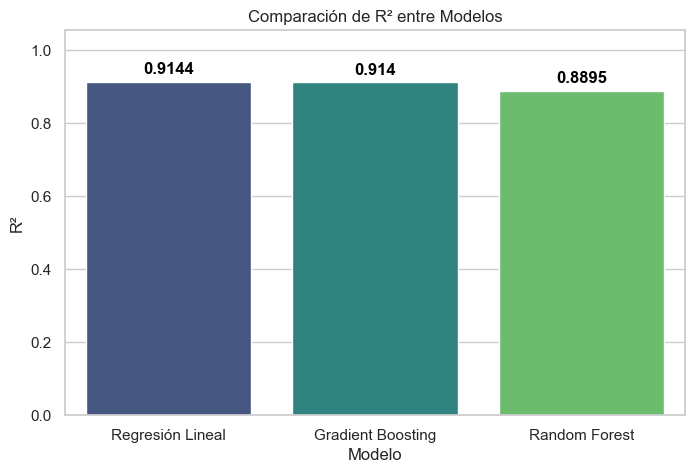

In [23]:
# Armamos una tabla con las métricas de los 3 modelos para comparar de un vistazo
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae_lineal, mae_rf, mae_gb],
    'RMSE': [rmse_lineal, rmse_rf, rmse_gb],
    'R2': [r2_lineal, r2_rf, r2_gb]
})

comparacion = comparacion.sort_values('R2', ascending=False).reset_index(drop=True)
print(comparacion)

# Gráfico de barras comparando el R2 de los 3 modelos
plt.figure(figsize=(8, 5))
sns.barplot(x='Modelo', y='R2', data=comparacion, palette='viridis')
plt.title('Comparación de R² entre Modelos')
plt.ylabel('R²')
plt.ylim(0, 1.055)  # Ajustamos un poco el límite superior para que el texto no quede cortado

# Añadir los valores numéricos sobre cada barra
for index, row in comparacion.iterrows():
    plt.text(
        index, 
        row['R2'] + 0.02,                   # Posición Y ligeramente por encima de la barra
        round(row['R2'], 4),                # Valor redondeado a 4 decimales
        color='black', 
        ha='center', 
        fontweight='bold'
    )

plt.show()

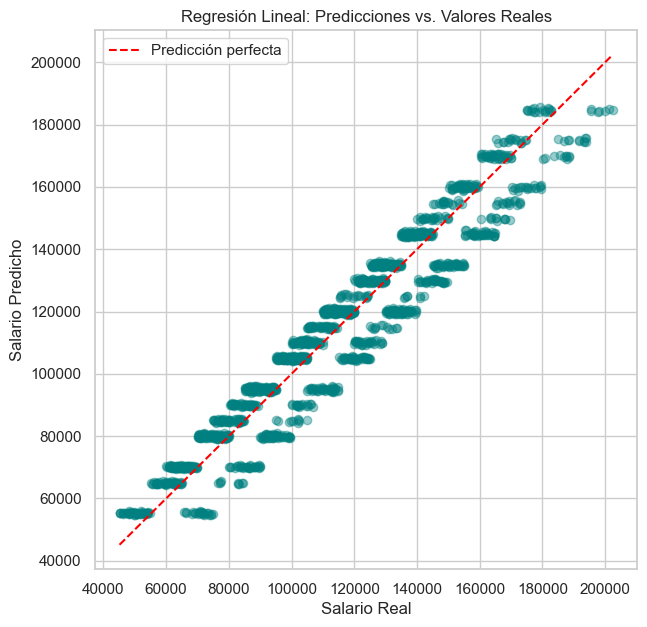

In [24]:
# Como la Regresión Lineal fue el mejor modelo, graficamos sus predicciones
# contra los valores reales para ver qué tan cerca están de la línea ideal
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_lineal, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         color='red', linestyle='--', label='Predicción perfecta')
plt.xlabel('Salario Real')
plt.ylabel('Salario Predicho')
plt.title('Regresión Lineal: Predicciones vs. Valores Reales')
plt.legend()
plt.show()

## 8. Interpretación: ¿Qué variables pesan más en el salario?
Como la Regresión Lineal fue el modelo con mejor desempeño, podemos revisar directamente sus coeficientes para entender qué variables aumentan o disminuyen el salario predicho. Esto es una ventaja de los modelos lineales frente a los más complejos: son más fáciles de interpretar.

Variables que más AUMENTAN el salario:
                                variable   coeficiente
5                 cat__cargo_AI Engineer  27041.387221
10  cat__cargo_Machine Learning Engineer  26372.300310
13         cat__nivel_experiencia_Senior  24949.516384
2                       scaler__skill_ml   7460.306127
3            scaler__skill_deep_learning   7366.809943
4                    scaler__skill_cloud   4833.587483
15                      cat__pais_Canada    294.448121
21                 cat__modalidad_Hybrid    240.276672
18                   cat__pais_Singapore    213.291736
12            cat__nivel_experiencia_Mid     45.682511

Variables que más REDUCEN el salario:
                        variable   coeficiente
14           cat__pais_Australia    -20.915307
19                  cat__pais_UK    -55.917091
16             cat__pais_Germany   -163.073971
22         cat__modalidad_Onsite   -240.826317
17               cat__pais_India   -263.359594
8       cat__cargo_Data Engineer -1

C:\Users\Pablo_Montenegro\AppData\Local\Temp\ipykernel_13576\4008156995.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coeficiente', y='variable', data=top_15, palette='coolwarm')


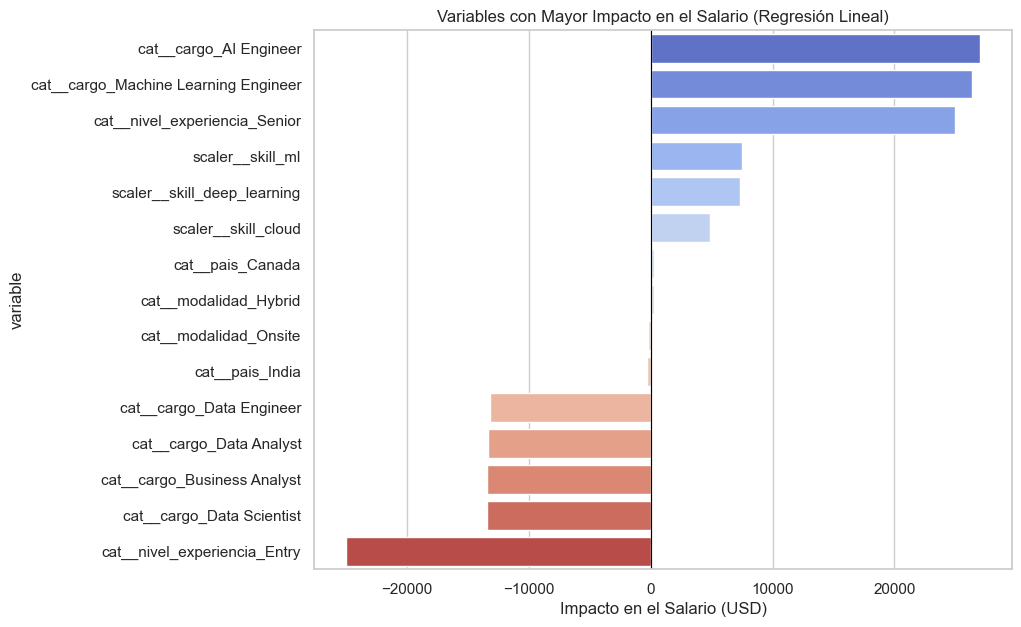

In [25]:
# Extraemos los nombres de las columnas que generó el One-Hot Encoding
nombres_columnas = modelo_lineal.named_steps['preprocesador'].get_feature_names_out()

# Extraemos los coeficientes del modelo entrenado
coeficientes = modelo_lineal.named_steps['regresor'].coef_

# Armamos una tabla ordenada de mayor a menor impacto
tabla_coef = pd.DataFrame({
    'variable': nombres_columnas,
    'coeficiente': coeficientes
}).sort_values('coeficiente', ascending=False)

# Mostramos las 10 variables que más aumentan el salario
print("Variables que más AUMENTAN el salario:")
print(tabla_coef.head(10))

print("\nVariables que más REDUCEN el salario:")
print(tabla_coef.tail(10))

# Graficamos las 10 con mayor impacto (positivo o negativo)
top_15 = pd.concat([tabla_coef.head(8), tabla_coef.tail(7)])
plt.figure(figsize=(9, 7))
sns.barplot(x='coeficiente', y='variable', data=top_15, palette='coolwarm')
plt.title('Variables con Mayor Impacto en el Salario (Regresión Lineal)')
plt.xlabel('Impacto en el Salario (USD)')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

**Nota sobre la escala de los coeficientes de las skills:** como `skill_ml`, `skill_deep_learning` y `skill_cloud` fueron estandarizadas, sus coeficientes están en una unidad distinta a las variables categóricas (que siguen siendo 0/1 por el One-Hot Encoding). Para estimar el efecto real de "tener la skill" frente a "no tenerla", se puede aproximar multiplicando el coeficiente por 2 (ya que la desviación estándar de una variable binaria balanceada es ≈0,5). Por ejemplo: `skill_ml` tiene un coeficiente de ~$7,460, lo que equivale a un efecto aproximado de ~$14,920 al comparar tener la skill vs. no tenerla — consistente con lo encontrado antes de aplicar el escalado.

## 9. Conclusiones del Proyecto

1. **Replanteamiento justificado del enfoque:** inicialmente se buscaba medir el crecimiento histórico de la demanda de los roles de Analista de Datos y Científico de Datos, pero la exploración inicial mostró que el dataset no presenta una tendencia temporal real (correlación año-demanda cercana a cero), por lo que el proyecto se reorientó hacia un problema de regresión salarial, igualmente relevante para el objetivo de orientación profesional.

2. **Comparación de modelos:** se entrenaron y compararon tres modelos de regresión. La Regresión Lineal obtuvo el mejor desempeño (R²=0,9144, MAE≈$7.593), seguida muy de cerca por Gradient Boosting (R²=0,9140), y por último Random Forest (R²=0,8896). El hecho de que un modelo simple como la Regresión Lineal supere a modelos más complejos indica que la relación entre las variables y el salario es, en su mayoría, lineal.

3. **Variables más influyentes:** el cargo (especialmente AI Engineer y Machine Learning Engineer) y el nivel de experiencia Senior son los factores que más impactan positivamente el salario. Sin embargo, las habilidades técnicas de Machine Learning, Deep Learning y Cloud también representan un incremento salarial significativo, independientemente del cargo.

4. **Implicación para la orientación profesional:** aunque los cargos de Analista de Datos y Científico de Datos parten de una base salarial menor que los roles de Ingeniería de IA/ML, el análisis muestra que desarrollar habilidades específicas (Machine Learning, Deep Learning, Cloud) es un camino concreto y medible para acercarse a los niveles salariales más altos del sector, sin necesidad de cambiar de rol.

5. **Limitación del estudio:** el dataset utilizado presenta características de datos sintéticos (fechas de publicación hasta 2026, variables sin relación temporal real), por lo que las conclusiones reflejan patrones estructurales del mercado modelado en el dataset, y se recomienda validar estos hallazgos con fuentes de datos reales del mercado laboral antes de tomar decisiones de carrera basadas únicamente en este análisis.